In [1]:
import joblib 
from utils.utils_2 import plot_most_accurate_window_angle_lstm, plot_most_accurate_window_lstm, visualize_attention_single_angle

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
scaler_X = MinMaxScaler()
dfs = pd.read_csv("../../../../../data/ml/features.csv", index_col="Time_[s]")
targets = pd.read_csv("../../../../../data/ml/targets.csv", index_col=False)
# df = dfs[dfs["Experiment_ID"]==2].drop(columns=["Experiment_ID"])
col = "Angle[degree]ORDistance[mm]"

scaler = MinMaxScaler(feature_range=(0, 1))
targets[col] = scaler.fit_transform(targets[[col]])
# See the first few rows
# bend_columns = [col for col in dfs.columns if 'BEND' in col]
# bend_columns.insert(0,'Experiment_ID')
# dfs = dfs.loc[:, bend_columns]
target = targets[targets["Experiment_ID"]==2]

In [3]:
groups_y = []
max_len_y = targets.groupby("Experiment_ID").size().max()
num_target_features = targets.shape[1] - 1  # exclude Experiment_ID

for exp_id, group in targets.groupby("Experiment_ID"):
    values = group.drop(columns=["Experiment_ID"]).values  # (len_group, num_target_features)
    
    # Pad with NaN
    padded = np.full((max_len_y, num_target_features), np.nan)
    padded[:values.shape[0], :] = values
    groups_y.append(padded)

# Final y: (num_experiments, max_len, num_target_features)
y = np.array(groups_y, dtype=float)

# Replace NaN with 0
Y = np.nan_to_num(y, nan=0.0)



groups = []
max_len = dfs.groupby("Experiment_ID").size().max()  # longest experiment
num_features = dfs.shape[1] - 1  # exclude Experiment_ID

for exp_id, group in dfs.groupby("Experiment_ID"):
    features = group.drop(columns=["Experiment_ID"]).values
    
    # Pad with NaN (or zeros) to match max_len
    padded = np.full((max_len, num_features), np.nan)  
    padded[:features.shape[0], :] = features
    groups.append(padded)


X = np.array(groups, dtype=float)
X = np.nan_to_num(X, nan=0.0)[:5,:,:]
Y = np.nan_to_num(y, nan=0.0)[:5,:,3:4]
print("Shape:", X.shape, Y.shape)  

Shape: (5, 1743, 17) (5, 47, 1)


In [4]:
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np

# Convert your data to PyTorch tensors
X_tensor = torch.tensor(X, dtype=torch.float32)  # (num_samples, seq_len, num_features)
Y_tensor = torch.tensor(Y, dtype=torch.float32)  # (num_samples, num_angles, 3)

# Split dataset into train and test (e.g., 80% train, 20% test)
dataset = TensorDataset(X_tensor, Y_tensor)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

# -------------------------
# Sinusoidal embedding
# -------------------------
def get_angle_embedding(angle_idx, hidden_dim, device):
    angle_idx = angle_idx.float().unsqueeze(1)  # (num_angles,1)
    div_term = torch.exp(torch.arange(0, hidden_dim, 2, device=device) *
                         -(math.log(10000.0)/hidden_dim))
    emb = torch.zeros((angle_idx.size(0), hidden_dim), device=device)
    emb[:, 0::2] = torch.sin(angle_idx * div_term)
    emb[:, 1::2] = torch.cos(angle_idx * div_term)
    return emb

# -------------------------
# Angle-conditioned Attention LSTM
# -------------------------
class AngleAttentionLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, num_angles, dropout=0.2):
        super().__init__()
        self.num_angles = num_angles
        self.hidden_size = hidden_size
        self.output_size = output_size

        # LSTM encoder
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, bidirectional=True, dropout=dropout)

        # Attention projections
        self.Wk = nn.Linear(hidden_size*2, hidden_size*2)  # key from LSTM
        self.Wq = nn.Linear(hidden_size*2, hidden_size*2)  # query from angle embedding

        # Fully connected output per angle
        self.fc = nn.ModuleList([nn.Linear(hidden_size*2, output_size) for _ in range(num_angles)])

    def forward(self, x):
        """
        x: (batch, seq_len, input_size)
        Returns:
            out: (batch, num_angles, output_size)
            attn_weights_all: (batch, num_angles, seq_len)
        """
        batch_size, seq_len, _ = x.size()
        lstm_out, _ = self.lstm(x)            # (batch, seq_len, hidden*2)
        K = self.Wk(lstm_out)                 # keys for attention

        # Precompute angle embeddings
        angle_indices = torch.arange(self.num_angles, device=x.device)
        angle_embs = get_angle_embedding(angle_indices, self.hidden_size*2, x.device)

        out_list = []
        attn_list = []

        for a in range(self.num_angles):
            # Query from angle embedding
            q = self.Wq(angle_embs[a]).unsqueeze(0).expand(batch_size, -1)  # (batch, hidden*2)

            # Attention scores (dot-product)
            scores = torch.bmm(K, q.unsqueeze(-1)).squeeze(-1) / math.sqrt(self.hidden_size*2)
            attn_weights = F.softmax(scores, dim=1)  # (batch, seq_len)
            attn_list.append(attn_weights)

            # Context vector
            context = torch.bmm(attn_weights.unsqueeze(1), lstm_out).squeeze(1)
            out_angle = self.fc[a](context)
            out_list.append(out_angle)

        out = torch.stack(out_list, dim=1)              # (batch, num_angles, output_size)
        attn_weights_all = torch.stack(attn_list, dim=1)  # (batch, num_angles, seq_len)
        return out, attn_weights_all

    @staticmethod
    def most_attended_timestep(attn_weights):
        # Returns argmax timestep per batch and angle
        return attn_weights.argmax(dim=-1)  # (batch, num_angles)


In [6]:
# === Model setup ===
input_size = X.shape[2]
hidden_size = 128
num_layers = 2
output_size = Y.shape[2]
num_angles = Y.shape[1]

model = AngleAttentionLSTM(input_size, hidden_size, num_layers, output_size, num_angles)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0001)

# Early stopping parameters
patience = 10
best_loss = float('inf')
counter = 0

# === Training loop with early stopping ===
num_epochs = 200
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        y_pred, _ = model(xb)
        loss = criterion(y_pred, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
    epoch_loss = running_loss / len(train_loader.dataset)
    
    # Evaluate on test set
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for xb, yb in test_loader:
            y_pred, _ = model(xb)
            loss = criterion(y_pred, yb)
            test_loss += loss.item() * xb.size(0)
    test_loss /= len(test_loader.dataset)

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_loss:.6f}, Test Loss: {test_loss:.6f}")

    # Early stopping check
    if test_loss < best_loss:
        best_loss = test_loss
        counter = 0
        joblib.dump(model, "lstm_2_1.joblib")
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

# === Load the best model for evaluation ===
joblib.dump(model, "lstm_2_1.joblib")
model.eval()

with torch.no_grad():
    Y_pred, attn_weights = model(X_tensor)
    Y_pred = Y_pred.cpu().numpy()
    attn_weights = attn_weights.cpu().numpy()


Epoch [1/200], Train Loss: 0.131854, Test Loss: 0.133708
Epoch [2/200], Train Loss: 0.130306, Test Loss: 0.132150
Epoch [3/200], Train Loss: 0.128771, Test Loss: 0.130601
Epoch [4/200], Train Loss: 0.127261, Test Loss: 0.129058
Epoch [5/200], Train Loss: 0.125748, Test Loss: 0.127516
Epoch [6/200], Train Loss: 0.124220, Test Loss: 0.125974
Epoch [7/200], Train Loss: 0.122717, Test Loss: 0.124426
Epoch [8/200], Train Loss: 0.121204, Test Loss: 0.122871
Epoch [9/200], Train Loss: 0.119643, Test Loss: 0.121303
Epoch [10/200], Train Loss: 0.118116, Test Loss: 0.119720
Epoch [11/200], Train Loss: 0.116562, Test Loss: 0.118117
Epoch [12/200], Train Loss: 0.114988, Test Loss: 0.116490
Epoch [13/200], Train Loss: 0.113405, Test Loss: 0.114835
Epoch [14/200], Train Loss: 0.111766, Test Loss: 0.113148
Epoch [15/200], Train Loss: 0.110113, Test Loss: 0.111423
Epoch [16/200], Train Loss: 0.108425, Test Loss: 0.109655
Epoch [17/200], Train Loss: 0.106681, Test Loss: 0.107839
Epoch [18/200], Train L

In [7]:
model = joblib.load("lstm_2_1.joblib")

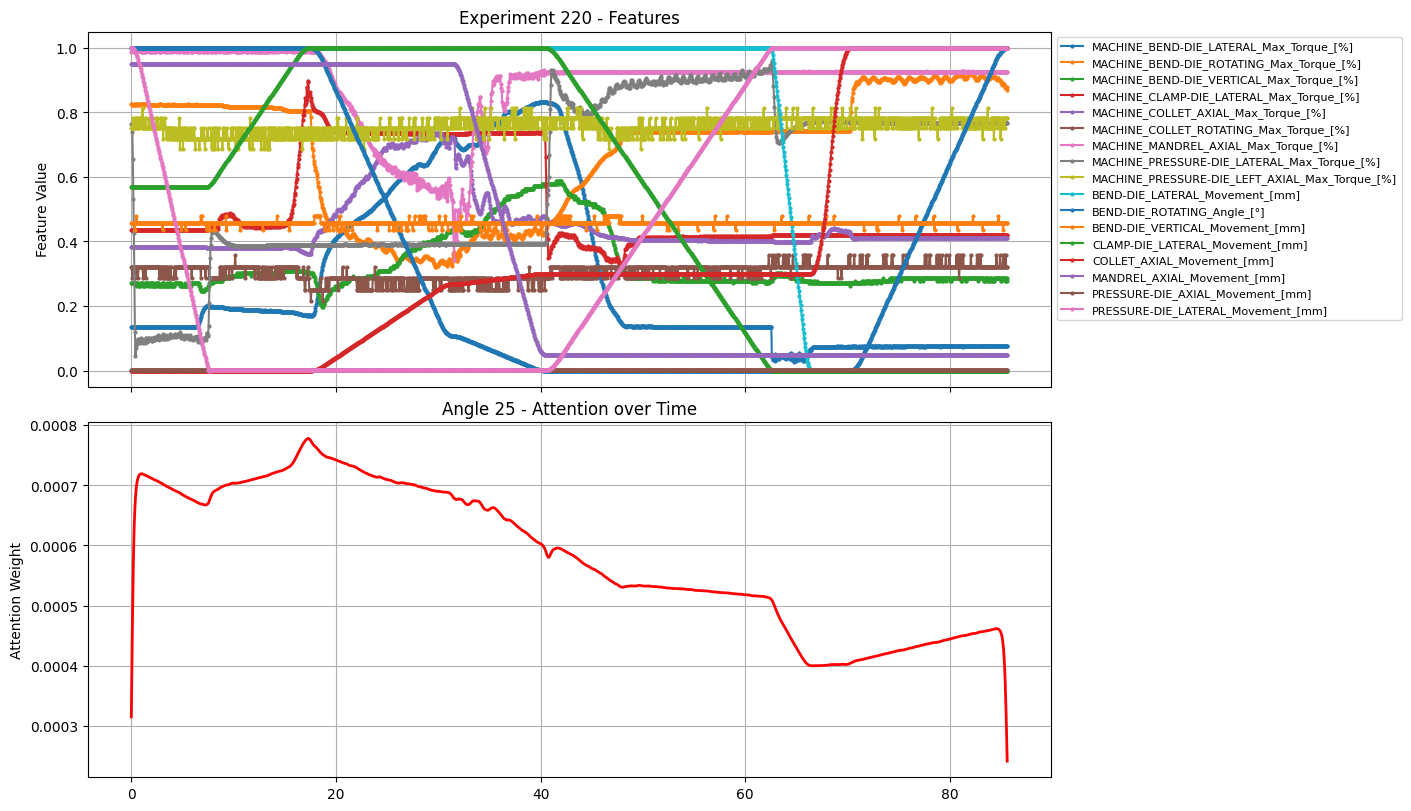

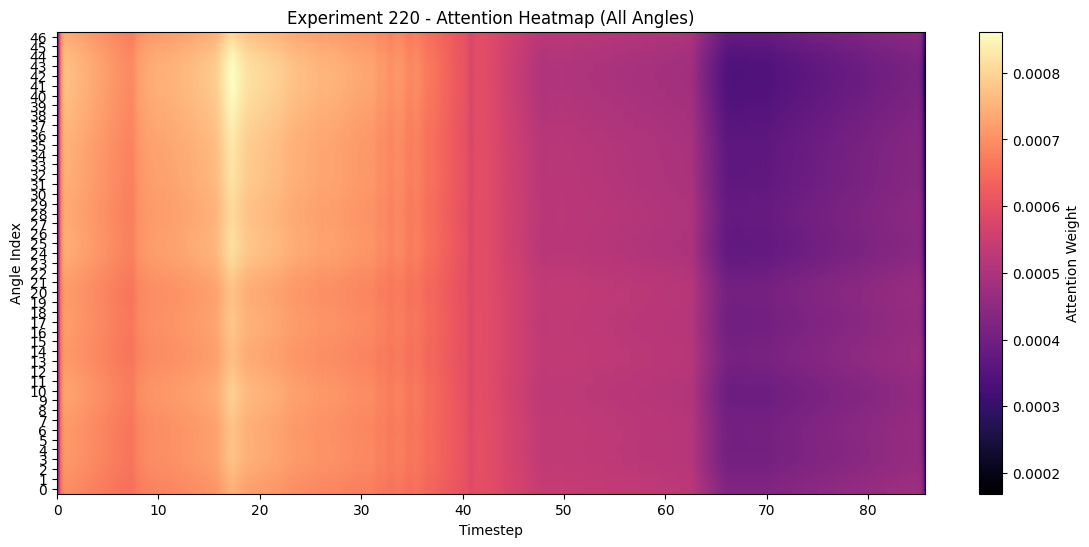

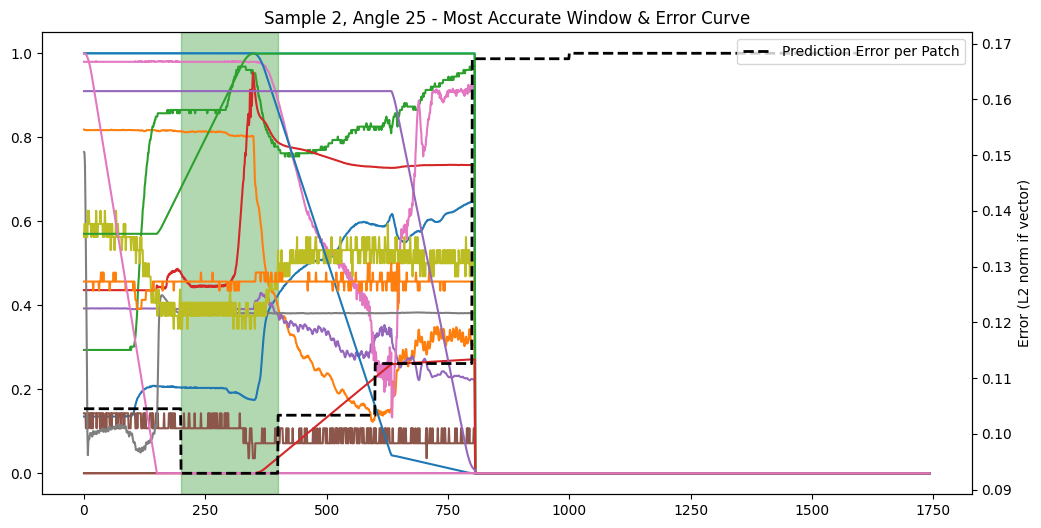

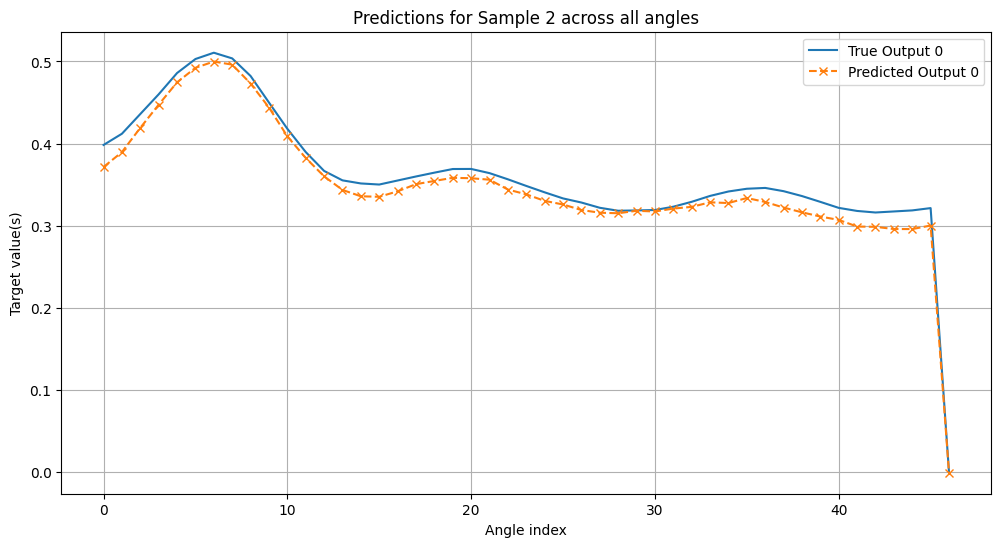

In [11]:
# Parameters
experiment_id, sample_idx = 220, 2
angle_idx = 25
patch_size = 200

visualize_attention_single_angle(experiment_id, angle_idx, model, dfs)
plot_most_accurate_window_angle_lstm(sample_idx, X, Y, model, Y.shape[1], X.shape[2], patch_size, angle_idx)

In [9]:
dfs['Experiment_ID'].unique()

array([  2,   4,   6,   8,  10,  12,  14,  16,  18,  20,  22,  24,  26,
        28,  30,  32,  34,  36,  38,  39,  40,  41,  42,  49,  55,  56,
        57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,  69,
        70,  71,  72,  73,  74,  75,  77,  78,  79,  80,  81,  82,  83,
        84,  85,  86,  87,  88, 119, 124, 190, 193, 196, 199, 202, 205,
       208, 211, 214, 217, 220, 223, 226, 229, 232, 235, 238, 241, 244,
       245, 246, 253, 254, 255, 262, 265, 268, 271, 274, 277, 280, 285,
       290, 293, 296, 299, 302, 305, 308, 311, 314])